In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import matplotlib.colors as base_colors
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
import intake
import colormaps as cmaps
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
catalog_url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
current_location = "NERSC"
catalog_model = "scream_ne120_inst"  # Use scream_ne120_inst for 2D instantaneous variables
# catalog_model = "scream_ne120"  # Use scream_ne120 for 3D 3h average variables
catalog_params = {"zoom": 8}

# Online catalog with current location
cat = intake.open_catalog(catalog_url)[current_location]
# Load dataset
ds = cat[catalog_model](**catalog_params).to_dask().pipe(egh.attach_coords, signed_lon=True)
ds

<xarray.Dataset> Size: 319GB
Dimensions:   (time: 3169, cell: 786432)
Coordinates:
  * time      (time) object 25kB 2019-08-01 00:00:00 ... 2020-09-01 00:00:00
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... -44.82 -45.18 -45.0
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
Data variables: (12/34)
    huss      (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    iwp       (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    lwp       (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    omega500  (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    omega700  (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    omega850  (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    ...        ...
    vas       (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    vivt      (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    zg300     (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    zg500     (time, cell) float32 10GB dask.array<chunksize=(24, 4096), meta=np.ndarray>
    ELEV      (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    LANDFRAC  (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          3
    averaging_frequency_units:    nhours
    averaging_type:               INSTANT
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [33]:
source = "scream"
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_dir = f"{root_dir}/{source}_allmasks_hp8_v1.zarr"

root_dir = "/pscratch/sd/w/wcmca1/hackathon/cof_masks/"
in_dir = f"{root_dir}/{source}_cofmasks_hp8_v1.zarr"

# Load mask dataset
print(f"Loading mask data from: {in_dir}")

dsm = xr.open_dataset(in_dir, mask_and_scale=False, engine='zarr')
dsm

Loading mask data from: /pscratch/sd/w/wcmca1/hackathon/cof_masks//scream_cofmasks_hp8_v1.zarr


<xarray.Dataset> Size: 104GB
Dimensions:                  (time: 1577, cell: 786432, crs: 0)
Coordinates:
  * cell                     (cell) int64 6MB 0 1 2 3 ... 786429 786430 786431
  * crs                      (crs) float64 0B 
  * time                     (time) datetime64[ns] 13kB 2019-08-01 ... 2020-0...
Data variables: (12/21)
    ar_etc_overlap_mask      (time, cell) float32 5GB ...
    ar_isolated_mask         (time, cell) float32 5GB ...
    ar_mask                  (time, cell) float32 5GB ...
    ar_mcs_etc_overlap_mask  (time, cell) float32 5GB ...
    ar_mcs_overlap_mask      (time, cell) float32 5GB ...
    cloud_types              (time, cell) float32 5GB ...
    ...                       ...
    mcs_etc_overlap_mask     (time, cell) float32 5GB ...
    mcs_isolated_mask        (time, cell) float32 5GB ...
    mcs_mask                 (time, cell) float32 5GB ...
    nd_pr                    (time, cell) float32 5GB ...
    st_pr                    (time, cell) float32 5GB ...
    tc_mask                  (time, cell) float32 5GB ...
Attributes: (12/46)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tc_filtering_threshold:       10%
    threads_per_worker:           1
    thresholds:                   MCS: 20%, AR: 10%, ETC: 5% (2-way), 0% (3-way)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

<Figure size 921.6x691.2 with 0 Axes>

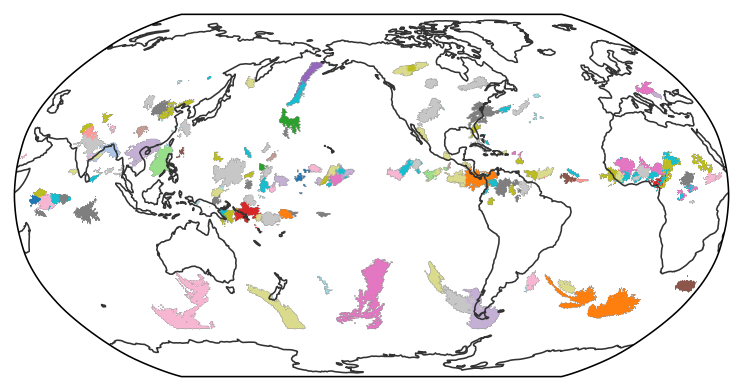

In [47]:
# itime = 1
# itime = '2020-05-02T12:00'
itime = '2019-08-03T00:00'

_dsm = dsm.sel(time=itime).squeeze()

mcs_mask = _dsm.mcs_mask
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

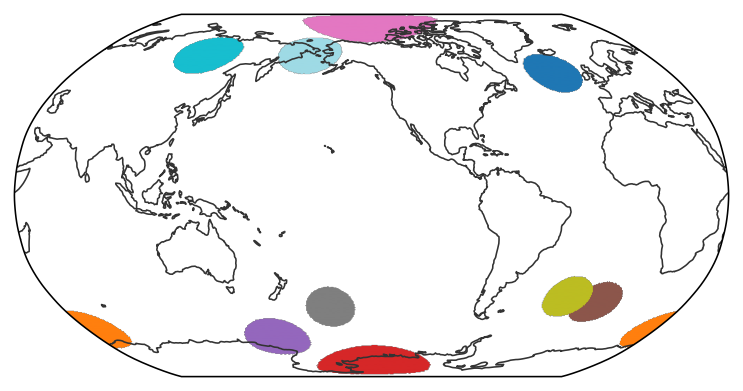

In [48]:
etc_mask = _dsm.etc_mask
egh.healpix_show(etc_mask.where(etc_mask > 0), cmap='tab20')

In [49]:
# ipsl = ds.psl.sel(time=itime).squeeze()
# # ipsl
# egh.healpix_contour(ipsl, cmap='viridis', vmin=95000, vmax=105000, linewidths=0.5)

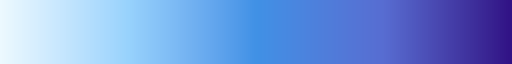

In [37]:
cmaps.blue_medb717b

<Figure size 921.6x691.2 with 0 Axes>

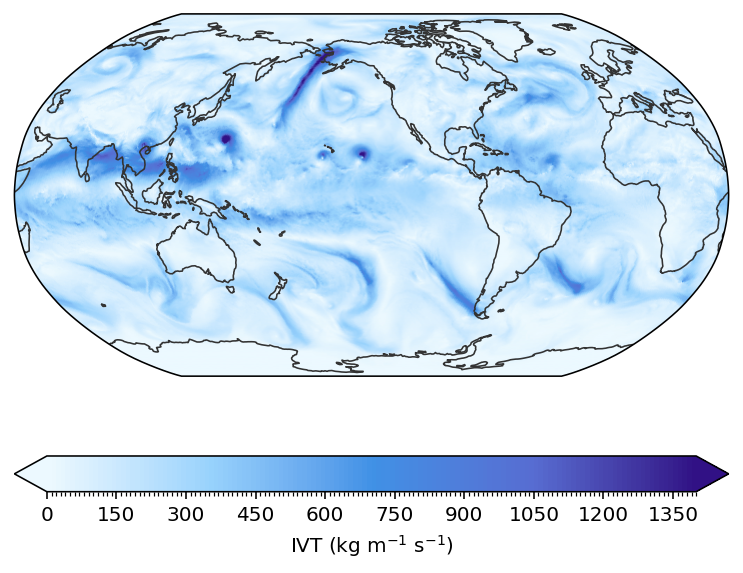

In [45]:
_ds = ds.sel(time=itime).squeeze()

# Compute total IVT
_uivt = _ds.uivt
_vivt = _ds.vivt
_ivt = np.sqrt(_uivt**2 + _vivt**2)
# Add IVT to dataset
_ds['IVT'] = _ivt

colormaps = cmaps.blue_medb717b
levels = np.arange(0, 1401, 10)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)
im = egh.healpix_show(_ds['IVT'], cmap=colormaps, norm=norm)
plt.colorbar(im, label='IVT (kg m$^{-1}$ s$^{-1}$)', orientation='horizontal', extend='both')

<Figure size 921.6x691.2 with 0 Axes>

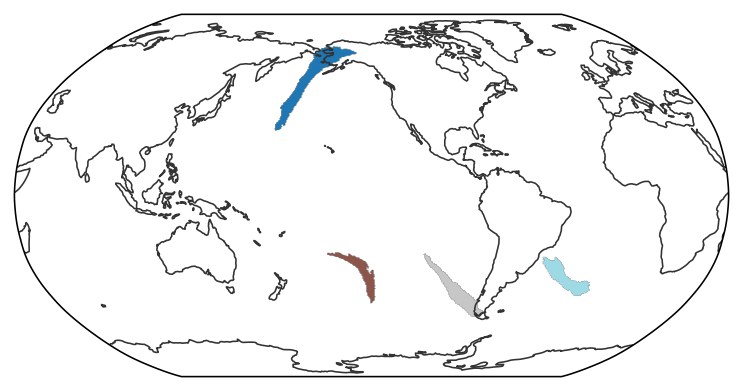

In [50]:
ar_mask = _dsm.ar_mask
egh.healpix_show(ar_mask.where(ar_mask > 0), cmap='tab20')

<Figure size 921.6x691.2 with 0 Axes>

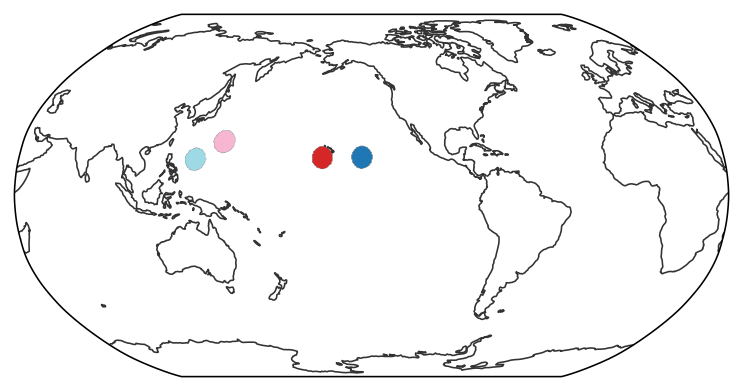

In [51]:
tc_mask = _dsm.tc_mask
egh.healpix_show(tc_mask.where(tc_mask > 0), cmap='tab20')

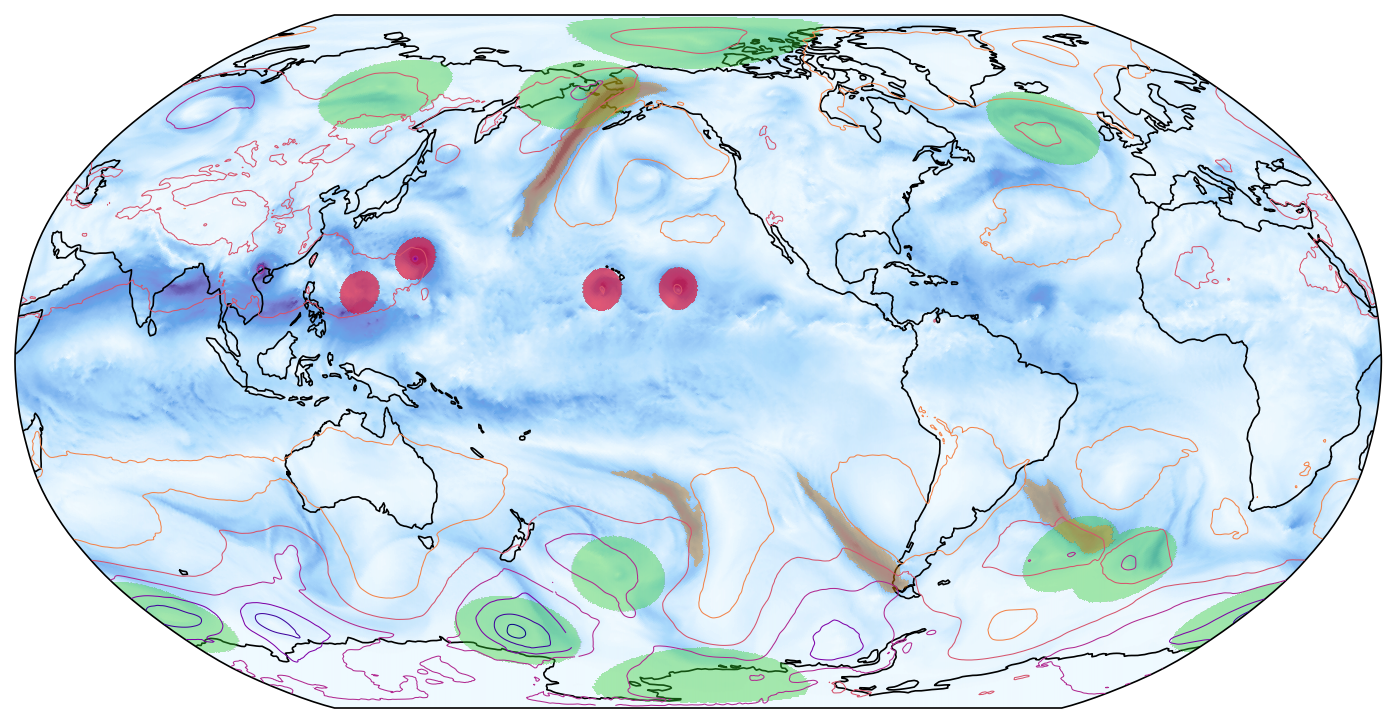

In [44]:
figsize = (12, 6)
dpi = 150
base_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
base_alphas = {
    'mcs': 0.8,
    # 'ar': 0.35,
    'ar': 0.4,
    'etc': 0.4,
    'tc': 0.7,
    'ivt': 0.8,
}
cmap_mcs = cmaps.cet_g_bw_minc_minl

# Create base map (integrated from worldmap_base)
projection = ccrs.Robinson(central_longitude=-135)
fig = plt.figure(figsize=figsize, dpi=dpi, facecolor='w')
ax = plt.subplot(111, projection=projection)
ax.set_global()
ax.add_feature(cf.COASTLINE, linewidth=0.8)
# ax.add_feature(cf.BORDERS, linewidth=0.4)

# Shade field as background
cmap_shade = cmaps.blue_medb717b
levels = np.arange(0, 1201, 10)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap_shade.N)
img_ivt = egh.healpix_show(_ivt, cmap=cmap_shade, norm=norm, ax=ax, alpha=base_alphas['ivt'], zorder=1)
# plt.colorbar(im, label='IVT (kg m$^{-1}$ s$^{-1}$)', orientation='horizontal', extend='both')

# Plot ETC mask with customizable colors and alpha
img_etc = egh.healpix_show(etc_mask.where(etc_mask > 0), ax=ax, 
            cmap=mpl.colors.ListedColormap([base_colors['etc']]), 
            alpha=base_alphas['etc'],
            vmin=0.5, vmax=1.5, zorder=2,
        )

# Plot AR mask with customizable colors and alpha
img_ar = egh.healpix_show(ar_mask.where(ar_mask > 0), ax=ax, 
            cmap=mpl.colors.ListedColormap([base_colors['ar']]), 
            alpha=base_alphas['ar'],
            vmin=0.5, vmax=1.5, zorder=3,
        )

# # Plot MCS mask with customizable colors and alpha
# img_mcs = egh.healpix_show(mcs_mask.where(mcs_mask > 0), ax=ax, 
#             # cmap=mpl.colors.ListedColormap([base_colors['mcs']]),
#             cmap=cmap_mcs, 
#             alpha=base_alphas['mcs'], zorder=4,
#             # vmin=0.5, vmax=1.5, zorder=4,
#         )

# Plot TC mask with customizable colors and alpha
img_tc = egh.healpix_show(tc_mask.where(tc_mask > 0), ax=ax, 
            cmap=mpl.colors.ListedColormap([base_colors['tc']]), 
            alpha=base_alphas['tc'],
            vmin=0.5, vmax=1.5, zorder=5,
        )

# Plot contours of PSL on top
img_psl = egh.healpix_contour(ipsl, cmap='plasma', vmin=95000, vmax=105000, linewidths=0.5, ax=ax, zorder=6)


In [89]:
def plot_feature_mask_with_field(
    ds, dsm, title="", figsize=(12, 6), 
    base_colors=None, base_alphas=None, text_colors=None,
    figname=None, dpi=200, 
    title_fontsize=14, legend_fontsize=12,
    # Mask plotting flags
    plot_mcs=False, plot_ar=True, plot_etc=True, plot_tc=True,
    # Track label flags
    show_mcs_labels=False, show_ar_labels=True, show_etc_labels=True, show_tc_labels=True,
    track_fontsize=12,
    # Shading options
    plot_shading=True, shade_var='IVT', shade_cmap=None, shade_levels=None,
    # Contour options
    plot_contour=True, contour_var='psl', contour_cmap=None, contour_levels=None, contour_lw=0.5,
    # MCS colormap
    mcs_cmap=None,
):
    """
    Plot feature masks with optional shading and contours.
    
    Parameters:
    -----------
    ds : xr.Dataset
        Dataset containing fields to plot (e.g., IVT, psl)
    dsm : xr.Dataset
        Dataset containing mask variables
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    base_colors : dict
        Colors for each feature type {'mcs': color, 'ar': color, 'etc': color, 'tc': color}
    base_alphas : dict
        Alpha values for each feature type and shading
    text_colors : dict
        Colors for track labels
    figname : str
        Output filename (if None, figure not saved)
    dpi : int
        Figure resolution
    title_fontsize : int
        Title font size
    legend_fontsize : int
        Legend font size
    plot_mcs : bool
        Whether to plot MCS masks
    plot_ar : bool
        Whether to plot AR masks
    plot_etc : bool
        Whether to plot ETC masks
    plot_tc : bool
        Whether to plot TC masks
    show_mcs_labels : bool
        Whether to show MCS track labels
    show_ar_labels : bool
        Whether to show AR track labels
    show_etc_labels : bool
        Whether to show ETC track labels
    show_tc_labels : bool
        Whether to show TC track labels
    track_fontsize : int
        Font size for track labels
    plot_shading : bool
        Whether to plot shaded background field
    shade_var : str
        Variable name for shading (must exist in ds)
    shade_cmap : colormap or None
        Colormap for shading
    shade_levels : array-like or None
        Levels for shading normalization
    plot_contour : bool
        Whether to plot contours
    contour_var : str
        Variable name for contours (must exist in ds)
    contour_cmap : str or None
        Colormap for contours
    contour_levels : array-like or None
        Contour levels
    contour_lw : float
        Contour line width
    mcs_cmap : colormap or None
        Colormap specifically for MCS masks
        
    Returns:
    --------
    figname : str or None
        Output filename
    """
    
    # Set default colors
    if base_colors is None:
        base_colors = {
            'mcs': 'lightskyblue',
            'ar': 'darkorange', 
            'etc': 'limegreen',
            'tc': 'red',
        }

    if text_colors is None:
        text_colors = {
            'mcs': 'navy',
            'ar': 'darkorange', 
            'etc': 'green',
            'tc': 'maroon',
        }
    
    if base_alphas is None:
        base_alphas = {
            'mcs': 0.8,
            'ar': 0.5,
            'etc': 0.5,
            'tc': 0.6,
            'shade': 0.9,
        }
    
    # Set default MCS colormap
    if mcs_cmap is None:
        mcs_cmap = cmaps.cet_g_bw_minc_minl
    
    # Set default shading colormap and levels
    if shade_cmap is None:
        shade_cmap = cmaps.blue_medb717b
    if shade_levels is None:
        shade_levels = np.arange(0, 1201, 10)
    
    # Set default contour levels and colormap
    if contour_levels is None:
        contour_levels = np.arange(95000, 105001, 1000)
    if contour_cmap is None:
        contour_cmap = 'plasma'

    # Extract individual masks (assuming single time step)
    mcs_mask = dsm['mcs_mask'].squeeze()
    ar_mask = dsm['ar_mask'].squeeze()
    etc_mask = dsm['etc_mask'].squeeze()
    tc_mask = dsm['tc_mask'].squeeze()

    # Convert individual masks to binary
    # mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)

    # Create base map
    projection = ccrs.Robinson(central_longitude=-135)
    fig = plt.figure(figsize=figsize, dpi=dpi, facecolor='w')
    ax = plt.subplot(111, projection=projection)
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else ""
    ax.set_title(plot_title, fontsize=title_fontsize)

    # Plot shaded background field if requested
    if plot_shading:
        shade_field = ds[shade_var].squeeze()
        norm = mpl.colors.BoundaryNorm(boundaries=shade_levels, ncolors=shade_cmap.N)
        alpha_shade = base_alphas.get('shade', 0.9)
        img_shade = egh.healpix_show(shade_field, cmap=shade_cmap, norm=norm, ax=ax, alpha=alpha_shade, zorder=1)

    # Plot masks based on flags
    zorder = 2
    
    # Plot ETC mask
    if plot_etc and np.any(etc_binary > 0):
        img_etc = egh.healpix_show(etc_binary.where(etc_binary > 0), ax=ax, 
                    cmap=mpl.colors.ListedColormap([base_colors['etc']]), 
                    alpha=base_alphas['etc'],
                    vmin=0.5, vmax=1.5, zorder=zorder)
        zorder += 1

    # Plot AR mask
    if plot_ar and np.any(ar_binary > 0):
        img_ar = egh.healpix_show(ar_binary.where(ar_binary > 0), ax=ax, 
                    cmap=mpl.colors.ListedColormap([base_colors['ar']]), 
                    alpha=base_alphas['ar'],
                    vmin=0.5, vmax=1.5, zorder=zorder)
        zorder += 1

    # Plot MCS mask
    if plot_mcs and np.any(mcs_mask > 0):
        img_mcs = egh.healpix_show(mcs_mask.where(mcs_mask > 0), ax=ax, 
                    cmap=mcs_cmap, 
                    alpha=base_alphas['mcs'], zorder=zorder)
        zorder += 1

    # Plot TC mask
    if plot_tc and np.any(tc_binary > 0):
        img_tc = egh.healpix_show(tc_binary.where(tc_binary > 0), ax=ax, 
                    cmap=mpl.colors.ListedColormap([base_colors['tc']]), 
                    alpha=base_alphas['tc'],
                    vmin=0.5, vmax=1.5, zorder=zorder)
        zorder += 1

    # Plot contours if requested
    if plot_contour:
        contour_field = ds[contour_var].squeeze()
        img_cont = egh.healpix_contour(contour_field, cmap=contour_cmap, levels=contour_levels, 
                                       linewidths=contour_lw, ax=ax, zorder=zorder)
        zorder += 1

    # Helper function for circular longitude averaging (handles dateline crossing)
    def circular_lon_mean(lon_values):
        """Calculate circular mean for longitude values to handle dateline crossing."""
        lon_rad = np.deg2rad(lon_values)
        mean_complex = np.mean(np.exp(1j * lon_rad))
        mean_lon = np.rad2deg(np.angle(mean_complex))
        if mean_lon < 0:
            mean_lon += 360
        return mean_lon
    
    # Add track labels for features if requested
    label_zorder = zorder
    
    # Add ETC track labels
    if show_etc_labels:
        etc_tracks = np.unique(etc_mask.values[etc_mask.values > 0])
        for track_id in etc_tracks:
            track_pixels = (etc_mask == track_id)
            if track_pixels.any():
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(), zorder=label_zorder,
                           fontsize=track_fontsize, fontweight='bold', 
                           color=text_colors['etc'], ha='center', va='center')
    
    # Add AR track labels
    if show_ar_labels:
        ar_tracks = np.unique(ar_mask.values[ar_mask.values > 0])
        for track_id in ar_tracks:
            track_pixels = (ar_mask == track_id)
            if track_pixels.any():
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(), zorder=label_zorder,
                           fontsize=track_fontsize, fontweight='bold', 
                           color=text_colors['ar'], ha='center', va='center')
    
    # Add TC track labels
    if show_tc_labels:
        tc_tracks = np.unique(tc_mask.values[tc_mask.values > 0])
        for track_id in tc_tracks:
            track_pixels = (tc_mask == track_id)
            if track_pixels.any():
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(), zorder=label_zorder,
                           fontsize=track_fontsize, fontweight='bold', 
                           color=text_colors['tc'], ha='center', va='center')
    
    # Add MCS track labels
    if show_mcs_labels:
        mcs_tracks = np.unique(mcs_mask.values[mcs_mask.values > 0])
        for track_id in mcs_tracks:
            track_pixels = (mcs_mask == track_id)
            if track_pixels.any():
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(), zorder=label_zorder,
                           fontsize=track_fontsize, fontweight='bold', 
                           color=text_colors['mcs'], ha='center', va='center')
    
    # Build legend dynamically based on what's being plotted
    legend_elements = []
    if plot_mcs:
        legend_elements.append(Patch(facecolor=base_colors['mcs'], alpha=base_alphas['mcs'], label='MCS'))
    if plot_ar:
        legend_elements.append(Patch(facecolor=base_colors['ar'], alpha=base_alphas['ar'], label='AR'))
    if plot_etc:
        legend_elements.append(Patch(facecolor=base_colors['etc'], alpha=base_alphas['etc'], label='ETC'))
    if plot_tc:
        legend_elements.append(Patch(facecolor=base_colors['tc'], alpha=base_alphas['tc'], label='TC'))
    
    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper right', fontsize=legend_fontsize, 
                  framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        fig.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")

    return fig


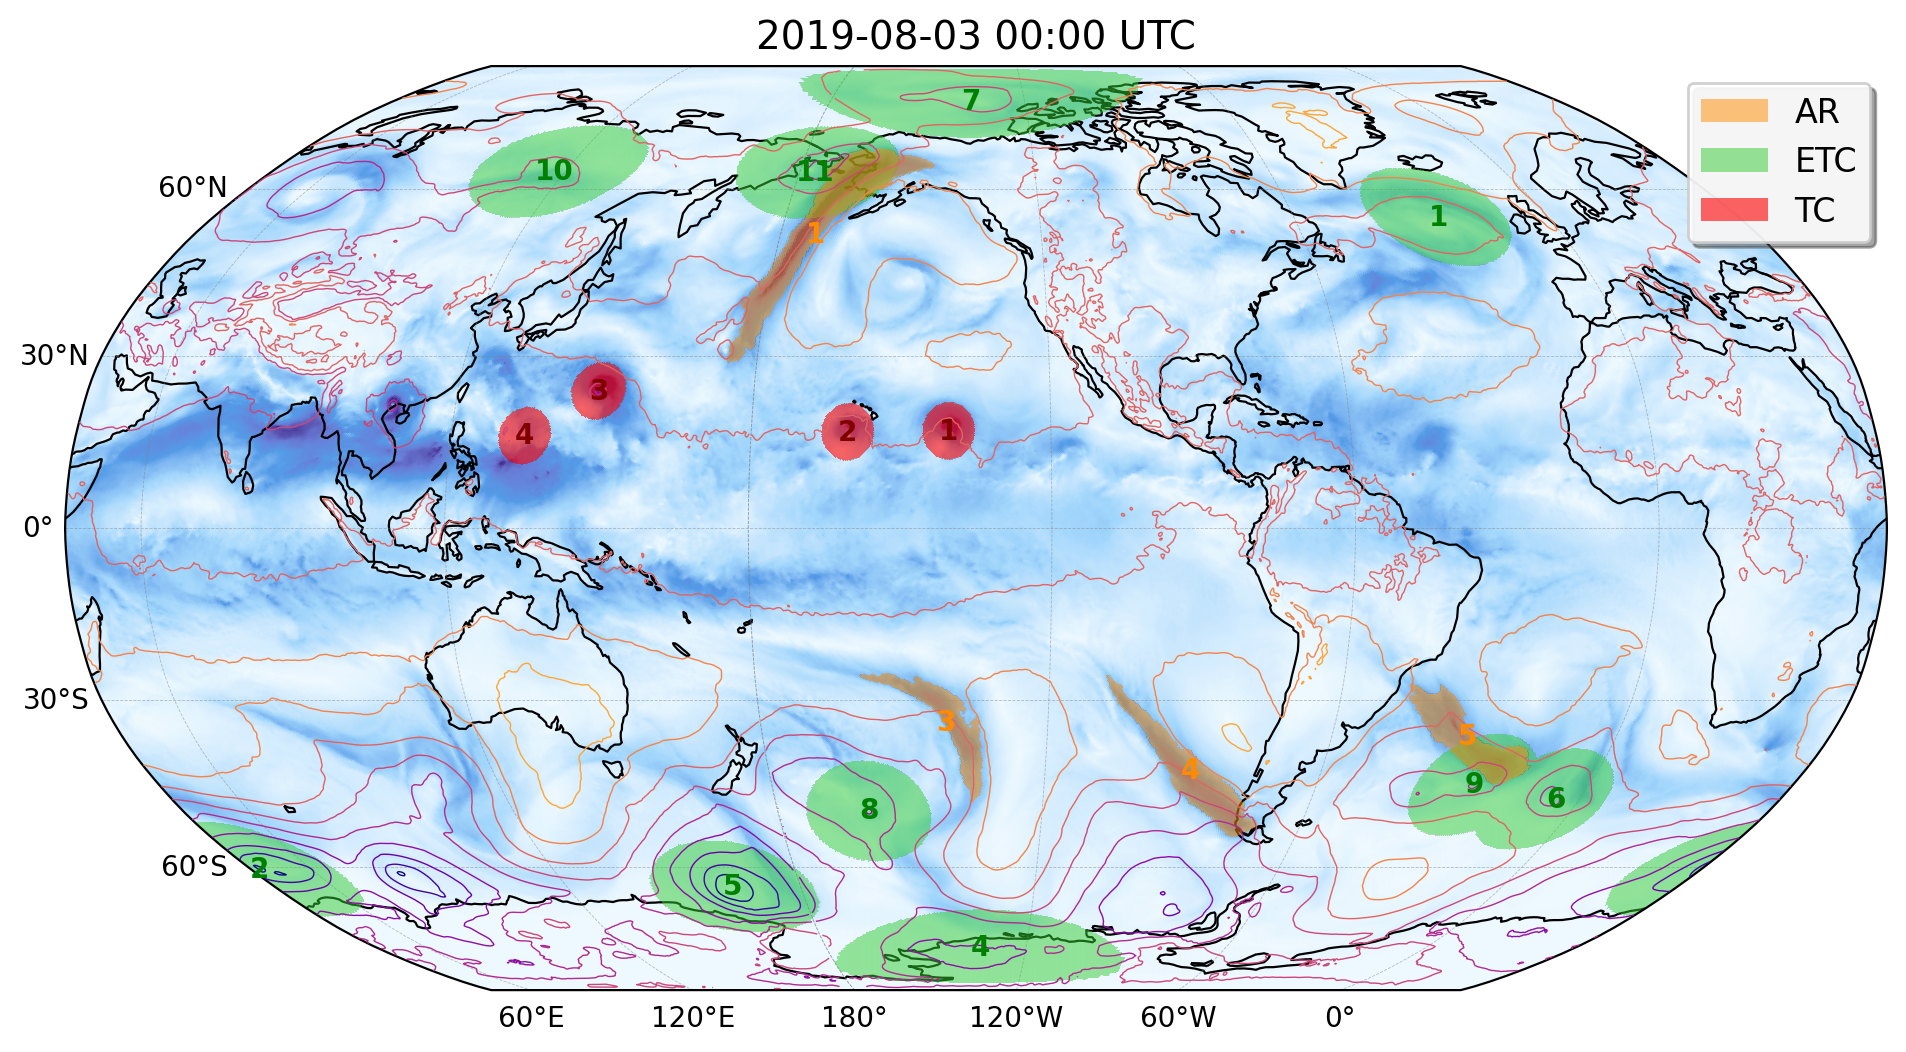

In [ ]:
# Format time for title and filename
time_label = _dsm.time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _dsm.time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{time_label}"

# Example 1: Plot all features with shading and contours (like before)
fig1 = plot_feature_mask_with_field(
    _ds, _dsm, title=title_with_time, figsize=(12, 6), 
    plot_mcs=False, plot_ar=True, plot_etc=True, plot_tc=True,
    show_mcs_labels=False, show_ar_labels=True, show_etc_labels=True, show_tc_labels=True,
    plot_shading=True, shade_var='IVT',
    plot_contour=True, contour_var='psl',
    contour_levels=np.arange(95000, 105001, 1000),
    contour_cmap='plasma', contour_lw=0.5,
    figname=None, dpi=200, 
    title_fontsize=14, legend_fontsize=12, 
    track_fontsize=10,
)

# Example 2: Plot only ETC masks without shading or contours
# fig2 = plot_feature_mask_with_field(
#     _ds, _dsm, title=f"ETC only - {time_label}", figsize=(12, 6), 
#     plot_mcs=False, plot_ar=False, plot_etc=True, plot_tc=False,
#     show_etc_labels=True,
#     plot_shading=False,
#     plot_contour=False,
#     figname=None, dpi=200,
# )

# Example 3: Plot with MCS using custom colormap
# fig3 = plot_feature_mask_with_field(
#     _ds, _dsm, title=f"With MCS - {time_label}", figsize=(12, 6), 
#     plot_mcs=True, plot_ar=True, plot_etc=True, plot_tc=True,
#     show_mcs_labels=True, show_ar_labels=True, show_etc_labels=True, show_tc_labels=True,
#     mcs_cmap=cmaps.cet_g_bw_minc_minl,
#     figname=None, dpi=200,
# )


In [87]:
time_label

'2019-08-03 00:00 UTC'

In [92]:
# catalog_model = "scream_ne120_inst"  # Use scream_ne120_inst for 2D instantaneous variables
# catalog_model = "scream_ne120"  # Use scream_ne120 for 3D 3h average variables
# catalog_params = {"zoom": 8}

# Load dataset
dsolr = cat["scream2D_hrly"](**catalog_params).to_dask().pipe(egh.attach_coords, signed_lon=True)
dsolr

<xarray.Dataset> Size: 60GB
Dimensions:   (time: 9457, cell: 786432)
Coordinates:
  * time      (time) object 76kB 2019-08-01 00:00:00 ... 2020-09-01 00:00:00
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... -44.82 -45.18 -45.0
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
Data variables:
    pr        (time, cell) float32 30GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    rlut      (time, cell) float32 30GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    ELEV      (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    LANDFRAC  (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          1
    averaging_frequency_units:    nhours
    averaging_type:               INSTANT
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [94]:
_dsolr = dsolr.sel(time=itime).squeeze()
_dsolr

<xarray.Dataset> Size: 31MB
Dimensions:   (cell: 786432)
Coordinates:
    time      object 8B 2019-08-03 00:00:00
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... -44.82 -45.18 -45.0
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
Data variables:
    pr        (cell) float32 3MB dask.array<chunksize=(262144,), meta=np.ndarray>
    rlut      (cell) float32 3MB dask.array<chunksize=(262144,), meta=np.ndarray>
    ELEV      (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
    LANDFRAC  (cell) float32 3MB dask.array<chunksize=(4096,), meta=np.ndarray>
Attributes: (12/22)
    Conventions:                  CF-1.8
    atm_initial_conditions_file:  /lustre/orion/cli115/world-shared/e3sm/inpu...
    averaging_frequency:          1
    averaging_frequency_units:    nhours
    averaging_type:               INSTANT
    case:                         cess-control.ne1024pg2_ne1024pg2.F2010-SCRE...
    ...                           ...
    product:                      model-output
    realm:                        atmos
    run_t0:                       2019-08-01-00000
    source:                       E3SM Atmosphere Model (EAMxx)
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel

In [96]:
_dsolr.rlut.min().values, _dsolr.rlut.max().values

(array(74.24539, dtype=float32), array(362.38306, dtype=float32))

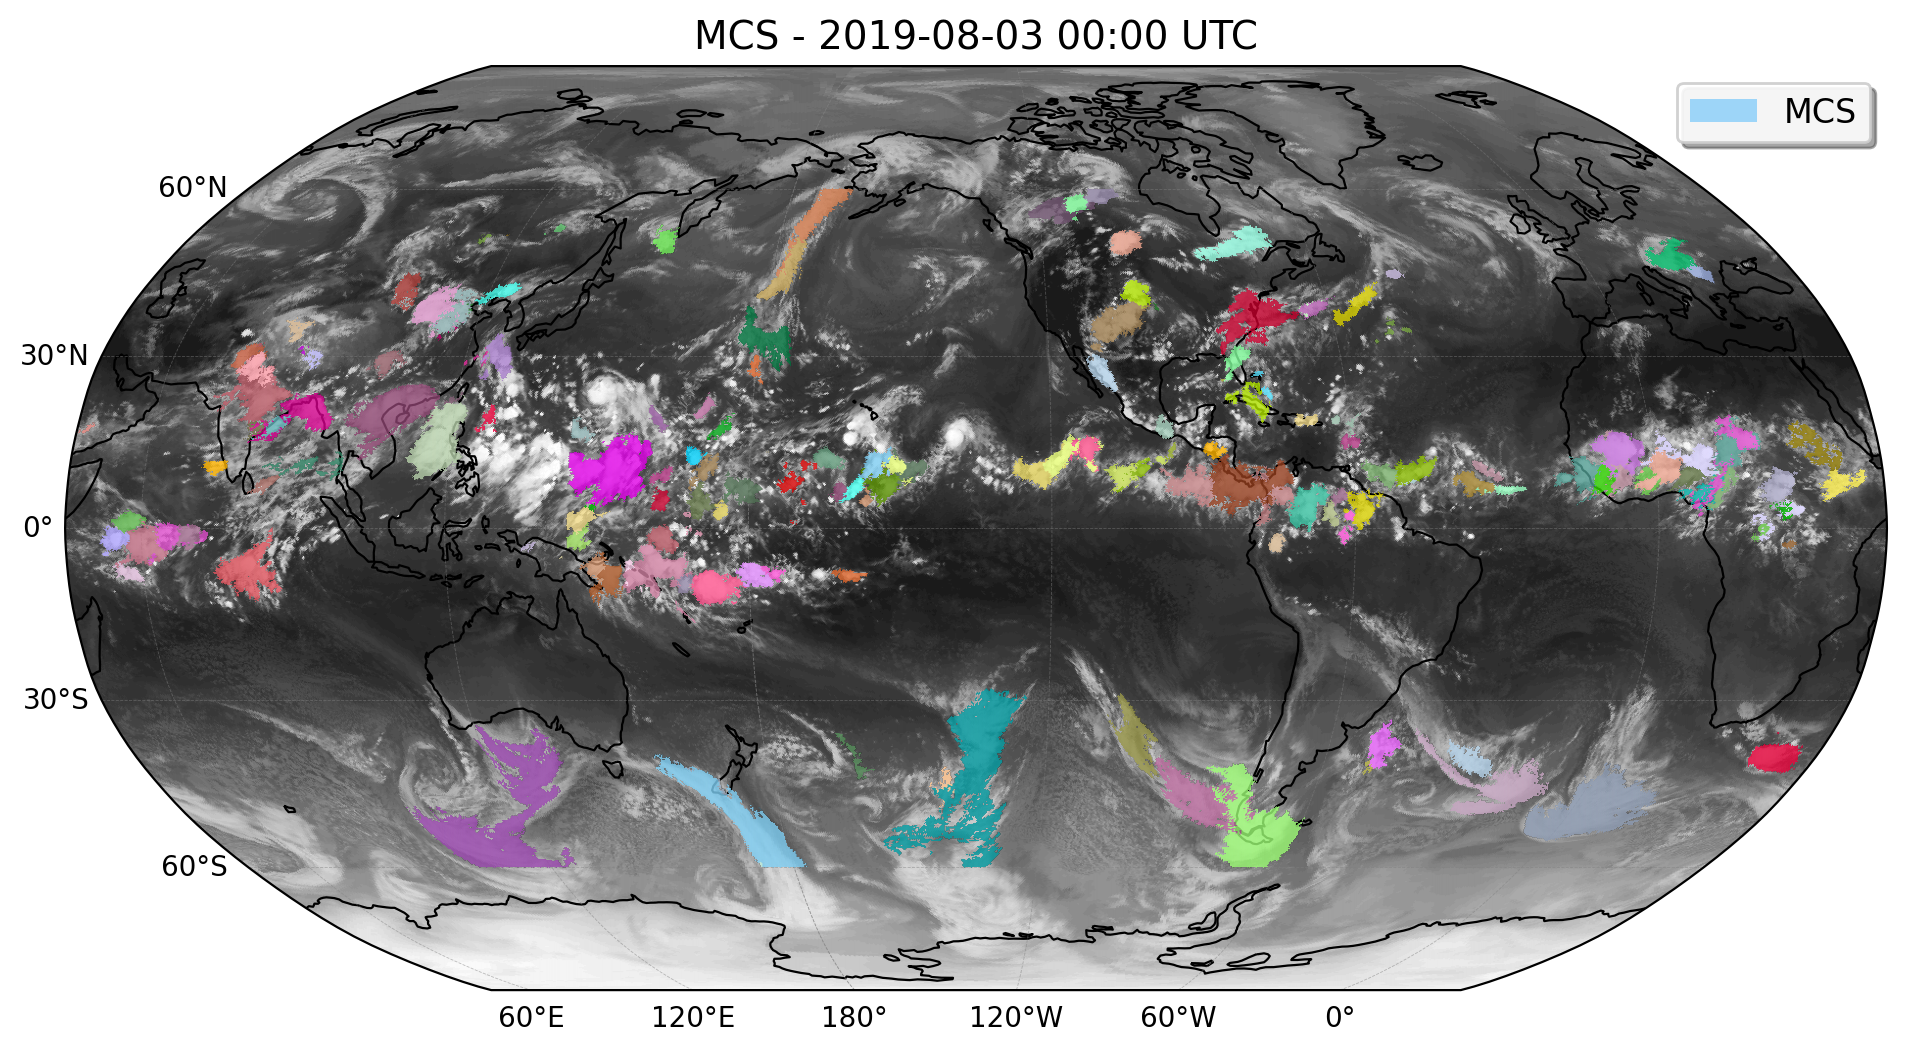

In [103]:
shade_levels = np.arange(80, 320, 5)

# Example 3: Plot with MCS using custom colormap
fig3 = plot_feature_mask_with_field(
    _dsolr, _dsm, title=f"MCS - {time_label}", figsize=(12, 6), 
    plot_mcs=True, plot_ar=False, plot_etc=False, plot_tc=False,
    show_mcs_labels=False, show_ar_labels=False, show_etc_labels=False, show_tc_labels=False,
    mcs_cmap=cmaps.cet_g_bw_minc_minl,
    plot_shading=True, shade_var='rlut', shade_cmap=cmaps.gray.reversed(), shade_levels=shade_levels,
    plot_contour=False, 
    # contour_levels=np.arange(95000, 105001, 1000),
    # contour_cmap='plasma', contour_lw=0.5,
    figname=None, dpi=200, 
    title_fontsize=14, legend_fontsize=12, 
    track_fontsize=10,
)